In [1]:
import tensorflow as tf
import tensorflow_datasets as tfds

(ds_train,ds_val),ds_info = tfds.load('cats_vs_dogs',
    split = ['train[:80%]','train[80%:]'],
    as_supervised=True,with_info=True
)

Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Generating splits...:   0%|          | 0/1 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/cats_vs_dogs/incomplete.UZ5YUI_4.0.1/cats_vs_dogs-train.tfrecord*...:   0%…

Dataset cats_vs_dogs downloaded and prepared to /root/tensorflow_datasets/cats_vs_dogs/4.0.1. Subsequent calls will reuse this data.


In [2]:
img_size = (224,224)
batch_size = 16

def preprocess(image,label):
  image = tf.image.resize(image,img_size)
  image = image/255.0
  return image,label

train_ds = ds_train.map(preprocess).shuffle(1000).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = ds_val.map(preprocess).batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [3]:
base_model = tf.keras.applications.VGG19(weights='imagenet',include_top=False,input_shape=(224,224,3))

for layer in base_model.layers:
  layer.trainable = False

80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [4]:
x = base_model.output
x = tf.keras.layers.Flatten()(x)
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.5)(x)
output = tf.keras.layers.Dense(1, activation='sigmoid')(x)

model = tf.keras.models.Model(inputs=base_model.input, outputs=output)

In [5]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [6]:
history = model.fit(train_ds,epochs=10,validation_data=val_ds)

Epoch 1/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 242s 195ms/step - accuracy: 0.8476 - loss: 0.3710 - val_accuracy: 0.8979 - val_loss: 0.2312
Epoch 2/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 215s 183ms/step - accuracy: 0.8805 - loss: 0.2736 - val_accuracy: 0.9037 - val_loss: 0.2394
Epoch 3/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 215s 184ms/step - accuracy: 0.8951 - loss: 0.2402 - val_accuracy: 0.9192 - val_loss: 0.1858
Epoch 4/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 215s 183ms/step - accuracy: 0.9079 - loss: 0.2151 - val_accuracy: 0.9205 - val_loss: 0.1855
Epoch 5/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 215s 183ms/step - accuracy: 0.9193 - loss: 0.1902 - val_accuracy: 0.9215 - val_loss: 0.1787
Epoch 6/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 214s 183ms/step - accuracy: 0.9217 - loss: 0.1796 - val_accuracy: 0.9228 - val_loss: 0.1856
Epoch 7/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 214s 183ms/step - accuracy: 0.9270 - loss: 0.1669 - val_accuracy: 0.9205 - val_loss: 0.1999
Epoch 8/10
1164/1164 ━━━━━━━━━━━━━━━━━━━━ 216s 183ms/step - ac

In [22]:
from google.colab import files
from tensorflow.keras.preprocessing import image
import numpy as np

uploaded = files.upload()

img_path = list(uploaded.keys())[0]
img = image.load_img(img_path, target_size=(224, 224))
img_array = image.img_to_array(img)

img_array = img_array / 255.0
img_array = np.expand_dims(img_array, axis=0)

predictions = model.predict(img_array)

if predictions[0] > 0.5:
    print("Dog")
else:
    print("Cat")

Saving test0004.webp to test0004.webp
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
Dog


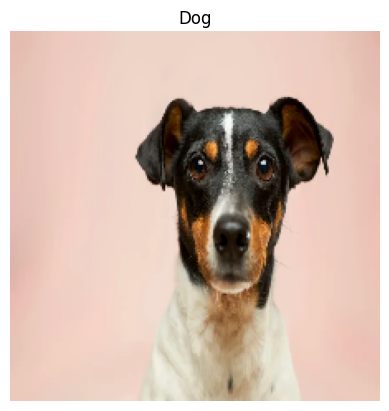

In [23]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.axis('off')

if predictions[0] > 0.5:
    plt.title("Dog")
else:
    plt.title("Cat")

plt.show()